In [126]:
%reload_ext autoreload
%autoreload 2

In [127]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# imports
from numba import cuda
import math
import matplotlib.pyplot as plt
import numpy as np
# modules
from modules.simulation import visibilities_simulation
from modules.plots import plot_uv_coverage_2, plot_uv_coverage


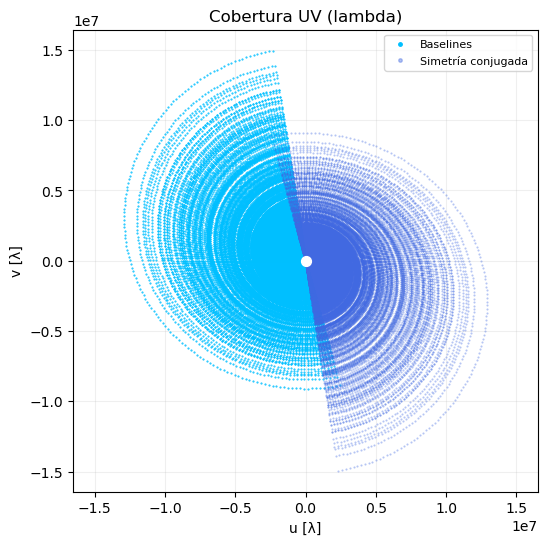

In [128]:
# simulate visibilities no grid
VLA_L_4 = {
  "latitude": 34.078749,
  "longitude": -107.617728,
  "file_route": "../antenna_arrays/vla.a.cfg",
  "catalog_source": "LMC",
  "utc_start": "2025-10-10T00:00:00",
  "utc_end": "2025-10-10T12:00:00",
  "step_min": 5,
  "n_freqs": 4,
  "interferometer": {
    "name": "VLA",
    "band_name": "L" },
  "n_sources": 100,
  "max_offset_deg": 0.1,
  "flux_range": [0.1, 2.0],
  "seed":42
  }

V, uvw, uvw_lambda, [frequencies, channel_bandwidth], baselines_enu, sources , [l,m,n] , times_sec = visibilities_simulation(VLA_L_4)

# plot_uv_coverage_2(uvw, 512, title="test")
plot_uv_coverage(uvw, unit='lambda')

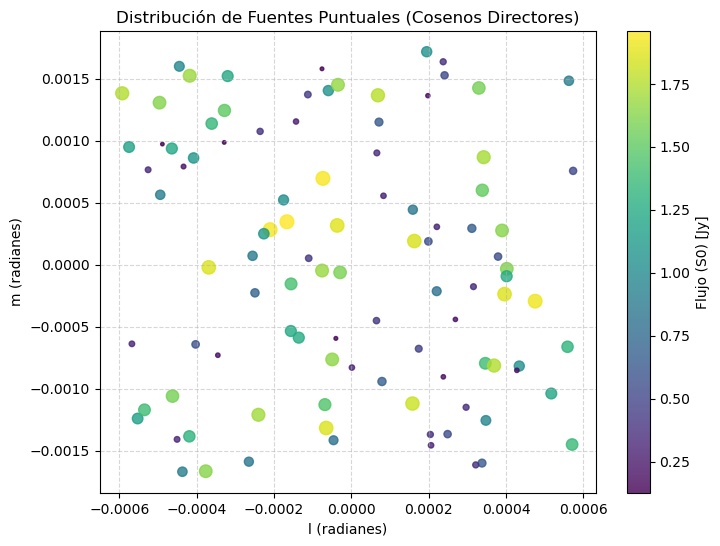

In [129]:
from modules.plots import plot_sources

plot_sources(l, m, sources)

In [144]:
# Gridding
from modules.gridder import grid_visibilities, get_grid_config

N = 1024

grid_config = get_grid_config(V, uvw_lambda, N, baselines_enu, oversampling_factor=2, frequencies=frequencies)
grid_config.keys()

dict_keys(['V', 'uvw_lambda', 'du', 'dv', 'Dmax', 'frequencies', 'oversampling_factor', 'baselines', 'Npix', 'pixel_size_image'])

In [145]:
VG, WG = grid_visibilities(grid_config=grid_config, mode="numpy")

Backend a utilizar: numpy


Generating plot with scale: 6 (Figure size: 6.0x6.0 inches)


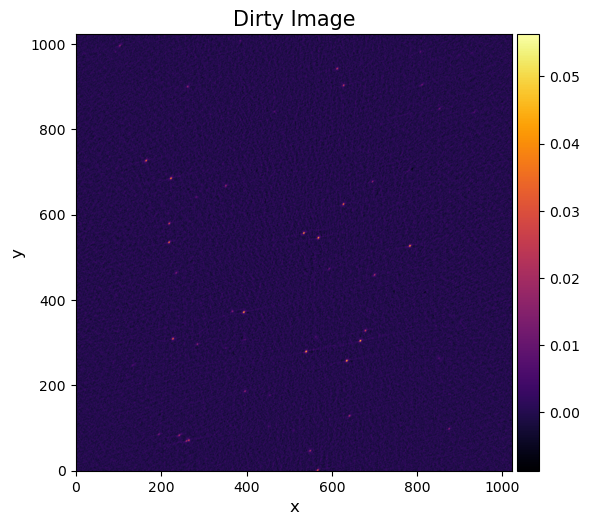

In [ ]:
from modules.interferometry import get_dirty_image
from modules.plots import plot

dirty_image = get_dirty_image(VG, WG)

images = [
    {'image':dirty_image, 'title':'Dirty Image', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
]

plot(images, (1,1), scale=6)

In [133]:

from mpl_toolkits.axes_grid1 import make_axes_locatable
from modules.interferometry import to_image


def plot_all_dirty_images(VG, cell_size_arcsec, num_channels):
    """
    Calcula y grafica la "dirty image" para cada canal de frecuencia en el cubo VG.
    """

    VG = np.asarray(VG)

    N, _  = VG.shape
    
    # Configura una grilla de subplots para mostrar todas las imágenes
    cols = math.ceil(math.sqrt(num_channels))
    rows = math.ceil(num_channels / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5), squeeze=False)
    fig.suptitle('Dirty Images por Canal de Frecuencia', fontsize=16)

    # Calcula el campo de visión para etiquetar los ejes correctamente
    image_fov_arcsec = N * cell_size_arcsec
    extent = [-image_fov_arcsec / 2, image_fov_arcsec / 2, -image_fov_arcsec / 2, image_fov_arcsec / 2]
    extent=[-1,1,-1,1]

    for i in range(num_channels):
        ax = axes[i // cols, i % cols]
        
        # Selecciona el canal y calcula la imagen
        image = to_image(VG[..., i])
        intensity = np.abs(image)
        intensity = intensity.get()
        
        im = ax.imshow(intensity, origin='lower', cmap='inferno', 
                       extent=extent)
        
        ax.set_title(f'Canal {i}')
        ax.set_xlabel('Offset RA (arcsec)')
        ax.set_ylabel('Offset Dec (arcsec)')

        # 1. Crea un divisor para el eje actual
        divider = make_axes_locatable(ax)
        # 2. Añade un nuevo eje a la derecha, del 5% del ancho de la imagen y con un poco de padding
        cax = divider.append_axes("right", size="5%", pad=0.1)
        # 3. Dibuja el colorbar en ese nuevo eje específico
        fig.colorbar(im, cax=cax, label='Intensidad')

    # Oculta los ejes de los subplots que no se usen
    for i in range(num_channels, rows * cols):
        axes[i // cols, i % cols].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

TypeError: Invalid shape (512,) for image data

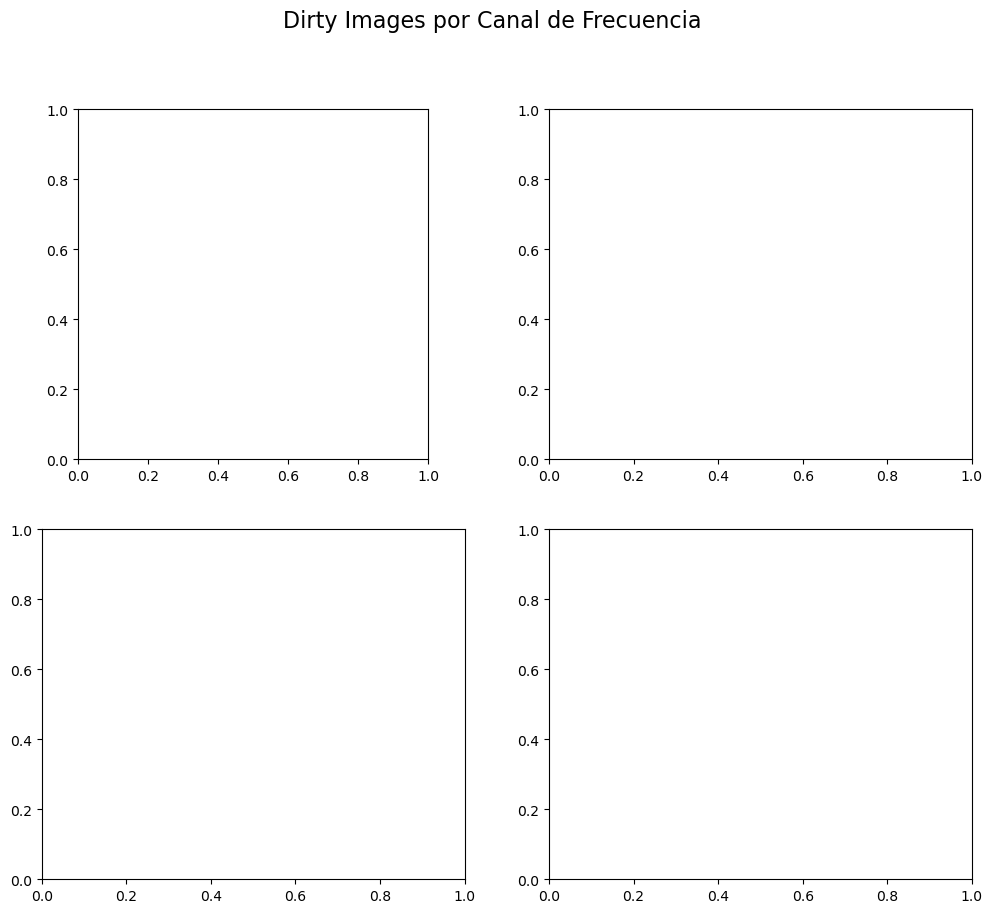

In [134]:
plot_all_dirty_images(VG, grid_config["du"], num_channels=4)